In [3]:
!pip install scikit-learn

In [1]:
import numpy as np

data = np.load("../96x96_tem_downsampled.npy")
data = data.squeeze()


print(type(data))
print(data.shape)

<class 'numpy.ndarray'>
(17266, 96, 96)


The dataset contains TEM images of many types - we want to extract crystalline/materials scans

In [2]:
from sklearn.preprocessing import StandardScaler

X = data.reshape(len(data), -1)
print(X.shape)

X = StandardScaler().fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

(17266, 9216)


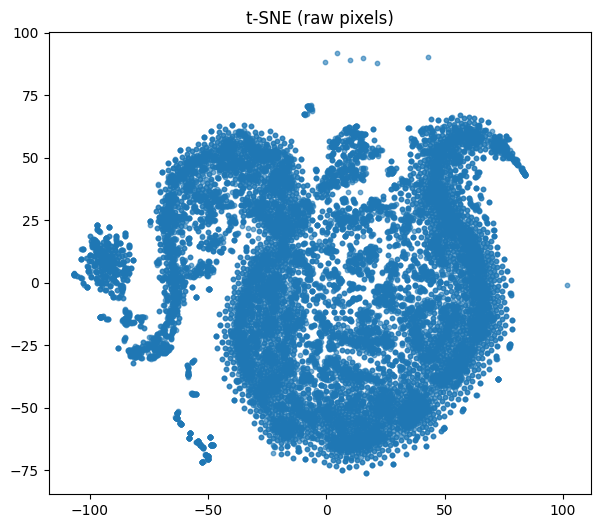

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_2d[:,0], X_2d[:,1], s=10, alpha=0.6)
plt.title("t-SNE (raw pixels)")
plt.show()

In [4]:
x = X_2d[:, 0]
y = X_2d[:, 1]

# create bins
nx, ny = 5, 5   # 4x4 grid (adjust if needed)

x_bins = np.linspace(x.min(), x.max(), nx + 1)
y_bins = np.linspace(y.min(), y.max(), ny + 1)

In [5]:
selected = []

for i in range(nx):
    for j in range(ny):

        # bin region
        mask = (
            (x >= x_bins[i]) & (x < x_bins[i+1]) &
            (y >= y_bins[j]) & (y < y_bins[j+1])
        )

        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            continue

        # pick representative (closest to bin center)
        cx = (x_bins[i] + x_bins[i+1]) / 2
        cy = (y_bins[j] + y_bins[j+1]) / 2

        d = (x[idxs] - cx)**2 + (y[idxs] - cy)**2
        selected.append(idxs[np.argmin(d)])

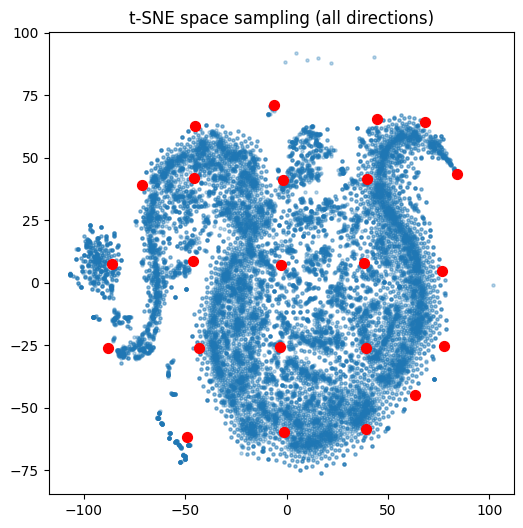

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X_2d[:,0], X_2d[:,1], s=5, alpha=0.3)
plt.scatter(X_2d[selected,0], X_2d[selected,1], c='red', s=50)

plt.title("t-SNE space sampling (all directions)")
plt.show()

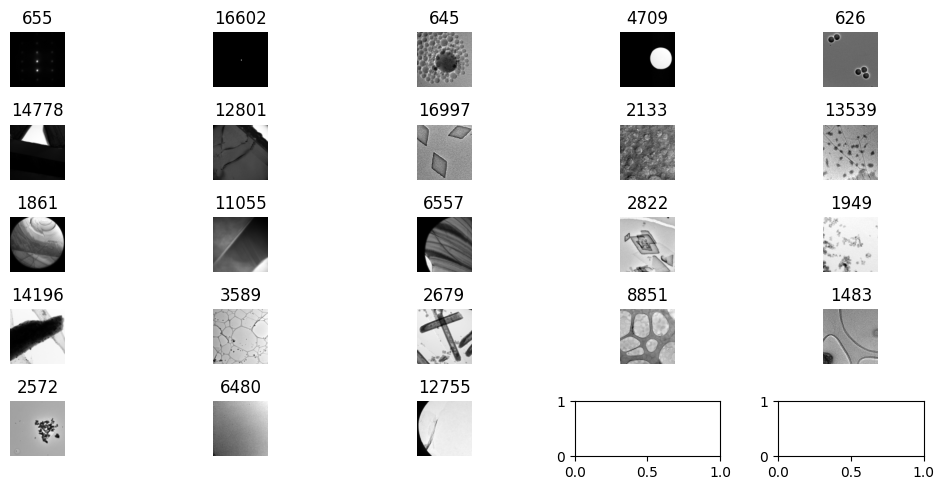

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(10,5))

for ax, i in zip(axes.ravel(), selected):
    ax.imshow(data[i].squeeze(), cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()